<!-- config-banner -->
# DINO 1° Tapenade adjoint — 180 d from rest (serial)

**`viscRef`** — 180 d serial adjoint from rest; `viscAhDfile` = `viscAhZfile` = `dino_viscAhD.bin`, the unscaled reference, via `PARM05`. Run 18232.


In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import xmitgcm
import matplotlib.pyplot as plt

import warnings; warnings.filterwarnings("ignore")

In [2]:
## analyze a sample run directory

# run_dir_srl = "/scratch2/tshahriar/DINO_1deg_tapAdj_runs/DINO_MITgcm_v011526_tapAdj_30d_run18238/"

run_dir_srl = "/scratch2/tshahriar/DINO_1deg_tapAdj_runs/runs_from_rest/DINO_1deg_tapAdj_180d_from_rest_viscRef_run18232/"

# run_dir_srl = "/scratch2/tshahriar/DINO_1deg_tapAdj_runs/runs_from_rest/DINO_1deg_tapAdj_360d_from_rest_viscRef_run18222/"

In [3]:
adxx_vars = {
    # 3D controls
    'adxx_theta': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_theta',
            'long_name': 'Sensitivity to Initial Potential Temperature',
            'units': 'dJ/K'
        }
    },

    'adxx_salt': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_salt',
            'long_name': 'Sensitivity to Initial Salinity',
            'units': 'dJ/(g kg-1)'
        }
    },

    'adxx_diffkr': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_diffkr',
            'long_name': 'Sensitivity to Diapycnal Diffusivity',
            'units': 'dJ/(m2/s)'
        }
    },
    
    'adxx_uvel': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_uvel',
            'long_name': 'Sensitivity to Initial Zonal Velocity',
            'units': 'dJ/(m/s)'
        }
    },

    'adxx_vvel': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_vvel',
            'long_name': 'Sensitivity to Initial Meridional Velocity',
            'units': 'dJ/(m/s)'
        }
    },

    # 2D time-dependent controls
    'adxx_tauu': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_tauu',
            'long_name': 'Sensitivity to Zonal Wind Stress Forcing',
            'units': 'dJ/(N/m2)'
        }
    },

    'adxx_tauv': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_tauv',
            'long_name': 'Sensitivity to Meridional Wind Stress Forcing',
            'units': 'dJ/(N/m2)'
        }
    },

    'adxx_qnet': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_qnet',
            'long_name': 'Sensitivity to Net Heat Flux',
            'units': 'dJ/(W/m2)'
        }
    },

    'adxx_qsw': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_qsw',
            'long_name': 'Sensitivity to Shortwave Radiation Flux',
            'units': 'dJ/(W/m2)'
        }
    },

    'adxx_empmr': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_empmr',
            'long_name': 'Sensitivity to Freshwater Flux (E−P−R)',
            'units': 'dJ/(m/s)'
        }
    },

    'adxx_uwind': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_uwind',
            'long_name': 'Sensitivity to Zonal Wind Speed',
            'units': 'dJ/(m/s)'
        }
    },

    'adxx_vwind': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_vwind',
            'long_name': 'Sensitivity to Meridional Wind Speed',
            'units': 'dJ/(m/s)'
        }
    },

    'adxx_fu': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_fu',
            'long_name': 'Sensitivity to Zonal Momentum Forcing (Fu)',
            'units': 'dJ/(m/s²)'
        }
    },

    'adxx_fv': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_fv',
            'long_name': 'Sensitivity to Meridional Momentum Forcing (Fv)',
            'units': 'dJ/(m/s²)'
        }
    }
}

In [4]:
adj_vars = {
    # 3D adjoint variables
    'ADJtheta': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJtheta',
            'long_name': 'Adjoint Sensitivity of Potential Temperature State',
            'units': 'dJ/dθ'
        }
    },

    'ADJsalt': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJsalt',
            'long_name': 'Adjoint Sensitivity of Salinity State',
            'units': 'dJ/dS'
        }
    },

    'ADJdiffkr': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJdiffkr',
            'long_name': 'Adjoint Sensitivity of Vertical Diffusivity',
            'units': 'dJ/d(diffkr)'
        }
    },

    # 3D adjoint for velocity fields
    'ADJuvel': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJuvel',
            'long_name': 'Adjoint Sensitivity of Zonal Velocity',
            'units': 'dJ/du'
        }
    },

    'ADJvvel': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJvvel',
            'long_name': 'Adjoint Sensitivity of Meridional Velocity',
            'units': 'dJ/dv'
        }
    },

    # 2D surface momentum adjoint
    'ADJtaux': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJtaux',
            'long_name': 'Adjoint Sensitivity of Zonal Surface Stress',
            'units': 'dJ/d(taux)'
        }
    },

    'ADJtauy': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJtauy',
            'long_name': 'Adjoint Sensitivity of Meridional Surface Stress',
            'units': 'dJ/d(tauy)'
        }
    },

    # 2D surface flux adjoints
    'ADJqnet': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJqnet',
            'long_name': 'Adjoint Sensitivity of Net Heat Flux',
            'units': 'dJ/d(qnet)'
        }
    },

    'ADJqsw': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJqsw',
            'long_name': 'Adjoint Sensitivity of Shortwave Radiation Flux',
            'units': 'dJ/d(qsw)'
        }
    },

    'ADJempmr': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJempmr',
            'long_name': 'Adjoint Sensitivity of Freshwater Flux (E–P–R)',
            'units': 'dJ/d(empmr)'
        }
    }
}

In [5]:
adxx_prefix = ['adxx_theta','adxx_salt','adxx_diffkr','adxx_uvel','adxx_vvel',
               'adxx_tauu','adxx_tauv','adxx_fu','adxx_fv',
               'adxx_uwind','adxx_vwind','adxx_qnet','adxx_qsw','adxx_empmr']

adj_prefix = ['ADJtheta','ADJsalt','ADJdiffkr','ADJtaux','ADJtauy', 'ADJuvel', 'ADJvvel',
              'ADJqnet','ADJqsw','ADJempmr']

In [6]:
ds_adxx = xmitgcm.open_mdsdataset(
    run_dir_srl,
    grid_dir=run_dir_srl,
    prefix=adxx_prefix,
    ref_date='2025-01-01',
    delta_t=1800,
    extra_variables=adxx_vars
)         

In [7]:
ds_adj = xmitgcm.open_mdsdataset(
    run_dir_srl,
    grid_dir=run_dir_srl,
    prefix=adj_prefix,
    ref_date='2025-01-01',
    delta_t=1800,
    extra_variables=adj_vars
)

In [8]:
# ds_adxx

In [9]:
# ds_adj

In [10]:
ds = xr.merge([ds_adj, ds_adxx])

In [11]:
ds

<xarray.Dataset>
Dimensions:      (time: 36, XC: 51, YC: 198, XG: 51, YG: 198, Z: 36, Zp1: 37,
                  Zu: 36, Zl: 36)
Coordinates: (12/37)
  * time         (time) datetime64[ns] 2025-01-01 2025-01-06 ... 2025-06-25
  * XC           (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC           (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
  * XG           (XG) >f4 -50.0 -49.0 -48.0 -47.0 -46.0 ... -3.0 -2.0 -1.0 0.0
  * YG           (YG) >f4 -69.68 -69.33 -68.97 -68.61 ... 68.97 69.33 69.68
  * Z            (Z) >f4 -5.069 -15.37 -26.01 ... -3.223e+03 -3.727e+03 -4.3e+03
    ...           ...
    maskCtrlW    (Z, YC, XG) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    maskCtrlS    (Z, YG, XC) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    dxF          (YC, XC) float32 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF          (YC, XC) float32 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV          (YG, XG) float32 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU          (YG, XG) float32 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables: (12/24)
    ADJsalt      (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJtauy      (time, YG, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJempmr     (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJqsw       (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJdiffkr    (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJuvel      (time, Z, YC, XG) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ...           ...
    adxx_qsw     (time, YC, XC) float64 dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    adxx_theta   (time, Z, YC, XC) float64 dask.array<chunksize=(36, 36, 198, 51), meta=np.ndarray>
    adxx_fu      (time, YC, XC) float64 dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    adxx_diffkr  (time, Z, YC, XC) float64 dask.array<chunksize=(36, 36, 198, 51), meta=np.ndarray>
    adxx_vvel    (time, Z, YC, XC) float64 dask.array<chunksize=(36, 36, 198, 51), meta=np.ndarray>
    adxx_tauv    (time, YC, XC) float64 dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [12]:
ds.adxx_diffkr.shape, ds.adxx_diffkr.dims

((36, 36, 198, 51), ('time', 'Z', 'YC', 'XC'))

In [13]:
ds_adj.ADJdiffkr.shape, ds_adj.ADJdiffkr.dims

((36, 36, 198, 51), ('time', 'Z', 'YC', 'XC'))

In [14]:
ds_adj.ADJtaux.shape, ds_adj.ADJtaux.dims

((36, 198, 51), ('time', 'YC', 'XG'))

In [15]:
ds_adj.ADJuvel.shape, ds_adj.ADJuvel.dims

((36, 36, 198, 51), ('time', 'Z', 'YC', 'XG'))

In [16]:
ds_adj.ADJvvel.shape, ds_adj.ADJvvel.dims

((36, 36, 198, 51), ('time', 'Z', 'YG', 'XC'))

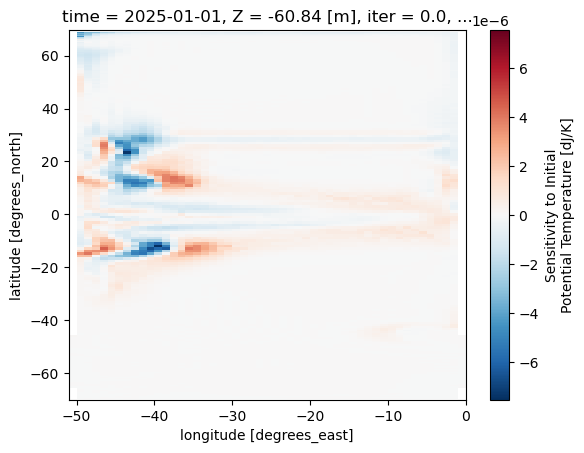

In [17]:
# Choose which time index to visualize
t_index = 0   # after 0 index, rest of the values are empty as adxx files contains the sensitivity wrt to the initial temperature only

# plotted the sensitivity field by applying the land mask. Everything in the ocean is 1 and outside ocean is 0.
ds.adxx_theta.isel(time=t_index, Z=5).where(ds.hFacC.isel(Z=5)).plot()

# #-- Uncomment lines below to control color scale and enhance contrast
# vmax = 1e-4; vmin = -vmax
# ds.adxx_theta.isel(time=t_index, Z=11).where(ds.hFacC.isel(Z=11)).plot(
#     vmin=vmin, vmax=vmax, cmap='RdBu_r'
# )

In [18]:
def print_stats(ds, var):
    da = ds[var].isel(time=0)  # all ADJ and adxx have time dimension
    arr = da.values
    arr_finite = arr[np.isfinite(arr)]
    if arr_finite.size == 0:
        print(f"{var:15s}: ALL NaN")
        return
    print(f"{var:15s}: min={arr_finite.min(): .3e}, "
          f"max={arr_finite.max(): .3e}, "
          f"L2={np.linalg.norm(arr_finite): .3e}")

In [19]:
print("=== adxx variables ===")
for var in adxx_prefix:
    if var in ds:
        print_stats(ds, var)
    else:
        print(f"{var:15s}: NOT FOUND")

print("\n=== ADJ variables ===")
for var in adj_prefix:
    if var in ds:
        print_stats(ds, var)
    else:
        print(f"{var:15s}: NOT FOUND")


=== adxx variables ===
adxx_theta     : min=-1.445e-03, max= 7.549e-04, L2= 1.419e-02
adxx_salt      : min=-3.452e-03, max= 7.875e-03, L2= 6.808e-02
adxx_diffkr    : min=-1.882e+00, max= 2.774e+00, L2= 9.684e+00
adxx_uvel      : min= 0.000e+00, max= 0.000e+00, L2= 0.000e+00
adxx_vvel      : min= 0.000e+00, max= 0.000e+00, L2= 0.000e+00
adxx_tauu      : min= 0.000e+00, max= 0.000e+00, L2= 0.000e+00
adxx_tauv      : min= 0.000e+00, max= 0.000e+00, L2= 0.000e+00
adxx_fu        : min=-5.913e-03, max= 4.252e-03, L2= 7.573e-02
adxx_fv        : min=-3.842e+01, max= 2.492e+02, L2= 1.163e+03
adxx_uwind     : min= 0.000e+00, max= 0.000e+00, L2= 0.000e+00
adxx_vwind     : min= 0.000e+00, max= 0.000e+00, L2= 0.000e+00
adxx_qnet      : min=-1.035e-03, max= 2.013e-03, L2= 7.375e-03
adxx_qsw       : min=-8.637e-08, max= 3.793e-07, L2= 1.709e-06
adxx_empmr     : min=-1.671e+02, max= 7.284e+02, L2= 2.833e+03

=== ADJ variables ===
ADJtheta       : min=-1.445e-03, max= 7.549e-04, L2= 1.419e-02
ADJsalt  

## Animation

In [20]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [21]:
def animate_ADJ_3d(var, ds, zlev=11, interval_ms=500):
    """
    Animate a 3D ADJ variable (e.g., ADJuvel, ADJvvel) at depth index zlev.
    """

    if var not in ds:
        print(f"{var} not in dataset.")
        return

    da = ds[var].isel(Z=zlev)

    # Apply land mask at same depth
    if 'hFacC' in ds:
        da = da.where(ds.hFacC.isel(Z=zlev) > 0)

    A = da.values

    # robust symmetric color scale
    if np.isfinite(A).any():
        v = np.nanpercentile(np.abs(A), 99)
        if v == 0 or not np.isfinite(v):
            v = 1.0
    else:
        v = 1.0

    vmin, vmax = -v, v

    print(f"{var}: shape={A.shape}, vmin={vmin:.3e}, vmax={vmax:.3e}")

    # time helper
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # --- figure setup ---
    fig, ax = plt.subplots(figsize=(10, 6))

    pcm = da.isel(time=0).plot(
        x='XC', y='YC',
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    # single colorbar
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(ds[var].attrs.get("long_name", var))

    title = ax.set_title(f"{var} • Z={zlev} • time={tlabel(0)}")
    ax.set_xlabel("Longitude (degrees east)")
    ax.set_ylabel("Latitude (degrees north)")

    # --- update ---
    def update(i):
        frame = da.isel(time=i).values
        pcm.set_array(frame.ravel())
        title.set_text(f"{var} • Z={zlev} • time={tlabel(i)}")
        return pcm, title

    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(fig, update, frames=frames,
                         interval=interval_ms, blit=False)

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [22]:
def animate_ADJ_2d(var, ds, mask_level=0, interval_ms=500):
    """
    Animate a 2D ADJ field (e.g., ADJqnet, ADJqsw, ADJempmr) over time.
    Uses hFacC at Z=mask_level as ocean mask and XC/YC for plotting.
    """
    if var not in ds:
        print(f"{var} not found in dataset.")
        return

    da = ds[var]

    # apply land mask (surface)
    if 'hFacC' in ds:
        mask = ds.hFacC.isel(Z=mask_level) > 0
        da = da.where(mask)

    A = da.values

    # robust symmetric color scale (99th percentile of |A|)
    if np.isfinite(A).any():
        v = np.nanpercentile(np.abs(A), 99)
        if v == 0 or not np.isfinite(v):
            v = 1.0
    else:
        v = 1.0
    vmin, vmax = -v, v

    print(f"{var}: shape={A.shape}, vmin={vmin:.3e}, vmax={vmax:.3e}")

    # time coord & label helper
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # --- figure setup ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # first frame: NO extra colorbar here
    pcm = da.isel(time=0).plot(
        x='XC', y='YC',
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    # single shared colorbar
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(da.attrs.get('long_name', var))

    title = ax.set_title(f"{var} • time={tlabel(0)}")
    ax.set_xlabel('Longitude (degrees east)')
    ax.set_ylabel('Latitude (degrees north)')

    # --- update: just change data + title, no clearing, no new colorbar ---
    def update(i):
        frame = da.isel(time=i).values
        pcm.set_array(frame.ravel())
        title.set_text(f"{var} • time={tlabel(i)}")
        return pcm, title

    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(
        fig, update,
        frames=frames,
        interval=interval_ms,
        blit=False
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [23]:
animate_ADJ_3d('ADJtheta', ds, zlev=11, interval_ms=500)

ADJtheta: shape=(36, 198, 51), vmin=-1.080e-05, vmax=1.080e-05


<IPython.core.display.HTML object>
[text/html animation output (2.4 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [24]:
animate_ADJ_3d('ADJsalt', ds, zlev=11, interval_ms=500)

ADJsalt: shape=(36, 198, 51), vmin=-3.124e-05, vmax=3.124e-05


<IPython.core.display.HTML object>
[text/html animation output (2.1 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [25]:
animate_ADJ_3d('ADJdiffkr', ds, zlev=11, interval_ms=500)

ADJdiffkr: shape=(36, 198, 51), vmin=-1.531e-02, vmax=1.531e-02


<IPython.core.display.HTML object>
[text/html animation output (2.3 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [26]:
print(ds['ADJtheta'].dims)
print(ds['ADJuvel'].dims)
print(ds['ADJvvel'].dims)

('time', 'Z', 'YC', 'XC')
('time', 'Z', 'YC', 'XG')
('time', 'Z', 'YG', 'XC')


In [27]:
def animate_ADJ_3d_updated(var, ds, zlev=11, interval_ms=500):

    if var not in ds:
        print(f"{var} not in dataset.")
        return

    da = ds[var].isel(Z=zlev)

    # Apply mask only for tracer grid
    if 'hFacC' in ds and 'XC' in da.dims and 'YC' in da.dims:
        da = da.where(ds.hFacC.isel(Z=zlev) > 0)

    A = da.values

    if np.isfinite(A).any():
        v = np.nanpercentile(np.abs(A), 99)
        if v == 0 or not np.isfinite(v):
            v = 1.0
    else:
        v = 1.0

    vmin, vmax = -v, v

    print(f"{var}: shape={A.shape}, vmin={vmin:.3e}, vmax={vmax:.3e}")

    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # grid-aware
    xcoord = 'XC' if 'XC' in da.dims else 'XG'
    ycoord = 'YC' if 'YC' in da.dims else 'YG'

    fig, ax = plt.subplots(figsize=(10, 6))

    # initial plot
    pcm = da.isel(time=0).plot(
        x=xcoord, y=ycoord,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(ds[var].attrs.get("long_name", var))

    title = ax.set_title(f"{var} • Z={zlev} • time={tlabel(0)}")

    # 🔑 ROBUST UPDATE: redraw instead of set_array
    def update(i):
        ax.clear()

        da.isel(time=i).plot(
            x=xcoord, y=ycoord,
            cmap='RdBu_r',
            vmin=vmin, vmax=vmax,
            add_colorbar=False,
            ax=ax
        )

        ax.set_title(f"{var} • Z={zlev} • time={tlabel(i)}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        return ax,

    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(fig, update, frames=frames,
                         interval=interval_ms, blit=False)

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [28]:
animate_ADJ_3d_updated('ADJuvel', ds, zlev=11, interval_ms=500)

ADJuvel: shape=(36, 198, 51), vmin=-2.210e-05, vmax=2.210e-05


<IPython.core.display.HTML object>
[text/html animation output (1.9 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [29]:
animate_ADJ_3d_updated('ADJvvel', ds, zlev=11, interval_ms=500)

ADJvvel: shape=(36, 198, 51), vmin=-1.680e-05, vmax=1.680e-05


<IPython.core.display.HTML object>
[text/html animation output (2.0 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [30]:
def animate_ADJ_2d_updated(var, ds, mask_level=0, interval_ms=500):
    """
    Animate a 2D ADJ field over time.
    Works for XC/YC, XG/YC, XC/YG (all staggered grids).
    """

    if var not in ds:
        print(f"{var} not found in dataset.")
        return

    da = ds[var]

    # Apply mask only for tracer grid
    if 'hFacC' in ds and 'XC' in da.dims and 'YC' in da.dims:
        mask = ds.hFacC.isel(Z=mask_level) > 0
        da = da.where(mask)

    A = da.values

    # robust symmetric color scale
    if np.isfinite(A).any():
        v = np.nanpercentile(np.abs(A), 99)
        if v == 0 or not np.isfinite(v):
            v = 1.0
    else:
        v = 1.0

    vmin, vmax = -v, v

    print(f"{var}: shape={A.shape}, vmin={vmin:.3e}, vmax={vmax:.3e}")

    # time helper
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # 🔑 grid-aware
    xcoord = 'XC' if 'XC' in da.dims else 'XG'
    ycoord = 'YC' if 'YC' in da.dims else 'YG'

    # --- figure ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # initial plot
    pcm = da.isel(time=0).plot(
        x=xcoord, y=ycoord,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(da.attrs.get('long_name', var))

    title = ax.set_title(f"{var} • time={tlabel(0)}")

    # 🔑 ROBUST UPDATE (no set_array)
    def update(i):
        ax.clear()

        da.isel(time=i).plot(
            x=xcoord, y=ycoord,
            cmap='RdBu_r',
            vmin=vmin, vmax=vmax,
            add_colorbar=False,
            ax=ax
        )

        ax.set_title(f"{var} • time={tlabel(i)}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        return ax,

    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(fig, update, frames=frames,
                         interval=interval_ms, blit=False)

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [31]:
print(ds['ADJtaux'].dims)
print(ds['ADJtauy'].dims)

('time', 'YC', 'XG')
('time', 'YG', 'XC')


In [32]:
animate_ADJ_2d_updated('ADJtaux', ds, mask_level=0, interval_ms=500)

ADJtaux: shape=(36, 198, 51), vmin=-2.057e-06, vmax=2.057e-06


<IPython.core.display.HTML object>
[text/html animation output (2.0 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [33]:
animate_ADJ_2d_updated('ADJtauy', ds, mask_level=0, interval_ms=500)

ADJtauy: shape=(36, 198, 51), vmin=-4.196e-03, vmax=4.196e-03


<IPython.core.display.HTML object>
[text/html animation output (2.1 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [34]:
animate_ADJ_2d_updated('ADJqnet',  ds, mask_level=0, interval_ms=500)

ADJqnet: shape=(36, 198, 51), vmin=-3.385e-08, vmax=3.385e-08


<IPython.core.display.HTML object>
[text/html animation output (2.0 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [35]:
animate_ADJ_2d_updated('ADJqsw',   ds, mask_level=0, interval_ms=500)

ADJqsw: shape=(36, 198, 51), vmin=-2.203e-11, vmax=2.203e-11


<IPython.core.display.HTML object>
[text/html animation output (2.1 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

In [36]:
animate_ADJ_2d_updated('ADJempmr', ds, mask_level=0, interval_ms=500)

ADJempmr: shape=(36, 198, 51), vmin=-1.417e-02, vmax=1.417e-02


<IPython.core.display.HTML object>
[text/html animation output (2.2 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

### Sensitivity to Temperature

In [37]:
# # --- settings ---
# var  = 'ADJtheta'   
# zlev = 11            # vertical level
# interval_ms = 500    # time between frames (ms)

# # --- slice + mask ---
# da_ADJtheta = ds[var].isel(Z=zlev)
# if 'hFacC' in ds:
#     da_ADJtheta = da_ADJtheta.where(ds.hFacC.isel(Z=zlev) > 0) # Keep all adjoint values where there is ocean (hFacC > 0), and replace everything over land with NaN.

In [38]:
# # --- robust symmetric color limits ---
# A_ADJtheta = da_ADJtheta.values # the adjoint sensitivity values-a numpy array (∂J/∂Θ) at every grid cell and time step at a specific vertical level

# # If any finite (non-NaN, non-inf) values exist in A, 
# # compute the 99th percentile of its absolute values; otherwise, just use 1.0.
# v_ADJtheta = np.nanpercentile(np.abs(A_ADJtheta), 99) if np.isfinite(A_ADJtheta).any() else 1.0
# vmin_ADJtheta, vmax_ADJtheta = -v_ADJtheta, v_ADJtheta

In [39]:
# ## for understanding

# print("Shape of A_ADJtheta:", A_ADJtheta.shape)
# print("Data type:", A_ADJtheta.dtype)
# print("Total elements:", A_ADJtheta.size)

# # Count valid (finite) values
# finite_mask = np.isfinite(A_ADJtheta)
# num_finite = np.count_nonzero(finite_mask)
# print("Finite values:", num_finite)
# print("NaNs or Infs:", A_ADJtheta.size - num_finite)

# if num_finite > 0:
#     Af = A_ADJtheta[finite_mask]  # flatten and remove NaNs/Infs
#     print(f"\nMin:  {Af.min():.3e}")
#     print(f"Max:  {Af.max():.3e}")
#     print(f"Mean: {Af.mean():.3e}")
#     print(f"Std:  {Af.std():.3e}")

#     # Print useful percentiles of absolute values
#     percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]
#     abs_perc = np.nanpercentile(np.abs(Af), percentiles)
#     print("\nPercentiles of |A_ADJtheta|:")
#     for p, v in zip(percentiles, abs_perc):
#         print(f" {p:>5.1f}th percentile: {v:.3e}")
# else:
#     print("\n⚠️ No finite values found in A_ADJtheta.")

In [40]:
# # helper for readable time label
# tcoord_ADJtheta = da_ADJtheta['time'].values # we grab the time coordinate from your DataArray da_ADJtheta

# def tlabel(i):
#     try:
#         return str(np.datetime_as_string(tcoord_ADJtheta[i], unit='D')) # YYYY-MM-DD only
#     except Exception:
#         return str(tcoord_ADJtheta[i])

In [41]:
# ## for understanding

# tcoord_ADJtheta

In [42]:
# # --- figure setup ---
# fig, ax = plt.subplots(figsize=(10, 6))

# # first frame
# h = da_ADJtheta.isel(time=0).plot(
#     x='XC', y='YC', cmap='RdBu_r',
#     vmin=vmin_ADJtheta, vmax=vmax_ADJtheta,
#     add_colorbar=True, ax=ax
# )

# title = ax.set_title(f"{var} • Z={zlev} • time={tlabel(0)}")
# ax.set_xlabel('Longitude (degrees east)')
# ax.set_ylabel('Latitude (degrees north)')

# # --- update function ---
# def update(i):
#     ax.clear()
#     da_ADJtheta.isel(time=i).plot(
#         x='XC', y='YC', cmap='RdBu_r',
#         vmin=vmin_ADJtheta, vmax=vmax_ADJtheta,
#         add_colorbar=False, ax=ax
#     )
#     ax.set_title(f"{var} • Z={zlev} • time={tlabel(i)}")
#     ax.set_xlabel('Longitude (degrees east)')
#     ax.set_ylabel('Latitude (degrees north)')
#     return ax

# # Create a reversed list of frame indices: [N-1, ..., 2, 1, 0]
# frames = list(reversed(range(da_ADJtheta.sizes['time'])))

# # --- Create and display animation ---

# # The FuncAnimation function builds the animation by repeatedly calling our `update()` function.
# # Each call updates the figure for one frame (one time step) in the dataset.
# # Arguments:
# #   fig        → the Matplotlib figure we created earlier (our plotting canvas)
# #   update     → the function that draws each new frame (defined above)
# #   frames     → total number of frames to animate; here equal to the number of time steps in `da`
# #   interval   → delay between frames in milliseconds (controls playback speed)
# #   blit=False → redraws the entire plot every frame; safer and more compatible in Jupyter notebooks
# #
# # Internally, this will:
# #   1. Start from the base figure
# #   2. Loop over each time index i = 0, 1, 2, ..., N-1
# #   3. Call update(i) to draw the i-th time slice
# #   4. Wait `interval_ms` milliseconds before the next frame
# #
# # `plt.close(fig)` prevents the static (non-animated) version of the figure from appearing above the animation.
# #
# # `HTML(anim.to_jshtml())` converts the animation to an interactive JavaScript-based HTML element
# # so that it plays inline directly inside the Jupyter notebook.
# #
# # Result: a smooth, inline animation that shows how the adjoint field evolves over time.

# # --- create animation ---
# anim = FuncAnimation(
#     fig,
#     update,
#     frames=frames,
#     interval=interval_ms,
#     blit=False
# )

# plt.close(fig)
# HTML(anim.to_jshtml())

In [43]:
# html = anim.to_jshtml()
# with open("ADJtheta_40N_Z11_360d.html", "w") as f:
#     f.write(html)

Note about the Above Plot

I had to plot the ADJtheta file in the reverse order of the timestep. This is because, ami forward model er time step use kortesi ADJtheta file k numbering korar jonno. But adjoint runs backward in time. So jokhon plot korbo tokhon seta ke reverse timestep order e plot korte hobe.

"ADJtheta.0000000000.data" data in this file should closely corresponds to the data in the file "adxx_theta.0000000000.data"


### Sensitivity to Vertical Diffusivity

In [44]:
# # --- settings ---
# var  = 'ADJdiffkr'   
# zlev = 11            # vertical level
# interval_ms = 500    # time between frames (ms)

# # --- slice + mask ---
# da_ADJdiffkr = ds[var].isel(Z=zlev)
# if 'hFacC' in ds:
#     da_ADJdiffkr = da_ADJdiffkr.where(ds.hFacC.isel(Z=zlev) > 0) # Keep all adjoint values where there is ocean (hFacC > 0), and replace everything over land with NaN.

In [45]:
# # --- robust symmetric color limits ---
# A_ADJdiffkr = da_ADJdiffkr.values # the adjoint sensitivity values-a numpy array (∂J/∂Θ) at every grid cell and time step at a specific vertical level

# # If any finite (non-NaN, non-inf) values exist in A, 
# # compute the 99th percentile of its absolute values; otherwise, just use 1.0.
# v_ADJdiffkr = np.nanpercentile(np.abs(A_ADJdiffkr), 99) if np.isfinite(A_ADJdiffkr).any() else 1.0
# vmin_ADJdiffkr, vmax_ADJdiffkr = -v_ADJdiffkr, v_ADJdiffkr

In [46]:
# ## for understanding

# print("Shape of A_ADJdiffkr:", A_ADJdiffkr.shape)
# print("Data type:", A_ADJdiffkr.dtype)
# print("Total elements:", A_ADJdiffkr.size)

# # Count valid (finite) values
# finite_mask = np.isfinite(A_ADJdiffkr)
# num_finite = np.count_nonzero(finite_mask)
# print("Finite values:", num_finite)
# print("NaNs or Infs:", A_ADJdiffkr.size - num_finite)

# if num_finite > 0:
#     Af = A_ADJdiffkr[finite_mask]  # flatten and remove NaNs/Infs
#     print(f"\nMin:  {Af.min():.3e}")
#     print(f"Max:  {Af.max():.3e}")
#     print(f"Mean: {Af.mean():.3e}")
#     print(f"Std:  {Af.std():.3e}")

#     # Print useful percentiles of absolute values
#     percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]
#     abs_perc = np.nanpercentile(np.abs(Af), percentiles)
#     print("\nPercentiles of |A_ADJdiffkr|:")
#     for p, v in zip(percentiles, abs_perc):
#         print(f" {p:>5.1f}th percentile: {v:.3e}")
# else:
#     print("\n⚠️ No finite values found in A_ADJdiffkr.")

In [47]:
# # helper for readable time label
# tcoord_ADJdiffkr = da_ADJdiffkr['time'].values # we grab the time coordinate from your DataArray da

# def tlabel(i):
#     try:
#         return str(np.datetime_as_string(tcoord_ADJdiffkr[i], unit='D')) # YYYY-MM-DD only
#     except Exception:
#         return str(tcoord[i])

In [48]:
# # --- figure setup ---
# fig, ax = plt.subplots(figsize=(10, 6))

# # first frame
# h = da_ADJdiffkr.isel(time=0).plot(
#     x='XC', y='YC', cmap='RdBu_r',
#     vmin=vmin_ADJdiffkr, vmax=vmax_ADJdiffkr,
#     add_colorbar=True, ax=ax
# )

# title = ax.set_title(f"{var} • Z={zlev} • time={tlabel(0)}")
# ax.set_xlabel('Longitude (degrees east)')
# ax.set_ylabel('Latitude (degrees north)')

# # --- update function ---
# def update(i):
#     ax.clear()
#     da_ADJdiffkr.isel(time=i).plot(
#         x='XC', y='YC', cmap='RdBu_r',
#         vmin=vmin_ADJdiffkr, vmax=vmax_ADJdiffkr,
#         add_colorbar=False, ax=ax
#     )
#     ax.set_title(f"{var} • Z={zlev} • time={tlabel(i)}")
#     ax.set_xlabel('Longitude (degrees east)')
#     ax.set_ylabel('Latitude (degrees north)')
#     return ax

# # Create a reversed list of frame indices: [N-1, ..., 2, 1, 0]
# frames = list(reversed(range(da_ADJdiffkr.sizes['time'])))

# # --- Create and display animation ---

# # The FuncAnimation function builds the animation by repeatedly calling our `update()` function.
# # Each call updates the figure for one frame (one time step) in the dataset.
# # Arguments:
# #   fig        → the Matplotlib figure we created earlier (our plotting canvas)
# #   update     → the function that draws each new frame (defined above)
# #   frames     → total number of frames to animate; here equal to the number of time steps in `da`
# #   interval   → delay between frames in milliseconds (controls playback speed)
# #   blit=False → redraws the entire plot every frame; safer and more compatible in Jupyter notebooks
# #
# # Internally, this will:
# #   1. Start from the base figure
# #   2. Loop over each time index i = 0, 1, 2, ..., N-1
# #   3. Call update(i) to draw the i-th time slice
# #   4. Wait `interval_ms` milliseconds before the next frame
# #
# # `plt.close(fig)` prevents the static (non-animated) version of the figure from appearing above the animation.
# #
# # `HTML(anim.to_jshtml())` converts the animation to an interactive JavaScript-based HTML element
# # so that it plays inline directly inside the Jupyter notebook.
# #
# # Result: a smooth, inline animation that shows how the adjoint field evolves over time.

# # --- create animation ---
# anim = FuncAnimation(
#     fig,
#     update,
#     frames=frames,
#     interval=interval_ms,
#     blit=False
# )

# plt.close(fig)
# HTML(anim.to_jshtml())

In [49]:
# html = anim.to_jshtml()
# with open("ADJdiffkr_40N_Z11_360d.html", "w") as f:
#     f.write(html)

### Sensitivity

### Sensitivity